In [8]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

BASE_DIR     = r"/Users/stevenhu/Downloads/QTM350 final project/API_NY.GDP.PCAP.KD_DS2_en_csv_v2_89"
MAIN_CSV     = os.path.join(BASE_DIR, "API_NY.GDP.PCAP.KD_DS2_en_csv_v2_89.csv")
COUNTRY_META = os.path.join(BASE_DIR, "Metadata_Country_API_NY.GDP.PCAP.KD_DS2_en_csv_v2_89.csv")

con = duckdb.connect()
print("Ready ✅")

Ready ✅


In [9]:
df_countries = con.execute(f"""
    WITH raw AS (
        SELECT * EXCLUDE ("2025", column70)
        FROM read_csv(
            '{MAIN_CSV}',
            skip = 4,
            header = true,
            ignore_errors = true
        )
    ),

    meta AS (
        SELECT
            "Country Code",
            Region,
            IncomeGroup
        FROM read_csv('{COUNTRY_META}', header = true)
        WHERE Region IS NOT NULL
          AND TRIM(Region) != ''
    ),

    unpivoted AS (
        UNPIVOT raw
        ON COLUMNS(* EXCLUDE ("Country Name", "Country Code", "Indicator Name", "Indicator Code"))
        INTO NAME Year VALUE GDP_per_capita
    ),

    cleaned AS (
        SELECT
            u."Country Name",
            u."Country Code",
            CAST(u.Year AS INTEGER)              AS Year,
            TRY_CAST(u.GDP_per_capita AS DOUBLE) AS GDP_per_capita,
            m.Region,
            m.IncomeGroup
        FROM unpivoted u
        INNER JOIN meta m
            ON u."Country Code" = m."Country Code"
        WHERE
            u.Year GLOB '[0-9][0-9][0-9][0-9]'
            AND TRY_CAST(u.GDP_per_capita AS DOUBLE) IS NOT NULL
    )

    SELECT * FROM cleaned
    ORDER BY "Country Name", Year
""").df()

print("Shape:", df_countries.shape)
print("Countries:", df_countries["Country Code"].nunique())
print("Year range:", df_countries["Year"].min(), "–", df_countries["Year"].max())
print("Missing GDP:", df_countries["GDP_per_capita"].isna().sum())
df_countries.head()

Shape: (11339, 6)
Countries: 213
Year range: 1960 – 2024
Missing GDP: 0


,Country Name,Country Code,Year,GDP_per_capita,Region,IncomeGroup
0,Afghanistan,AFG,2000,308.318270,Middle East & North Africa,Low income
1,Afghanistan,AFG,2001,277.118051,Middle East & North Africa,Low income
2,Afghanistan,AFG,2002,338.139974,Middle East & North Africa,Low income
3,Afghanistan,AFG,2003,346.071627,Middle East & North Africa,Low income
4,Afghanistan,AFG,2004,338.637274,Middle East & North Africa,Low income


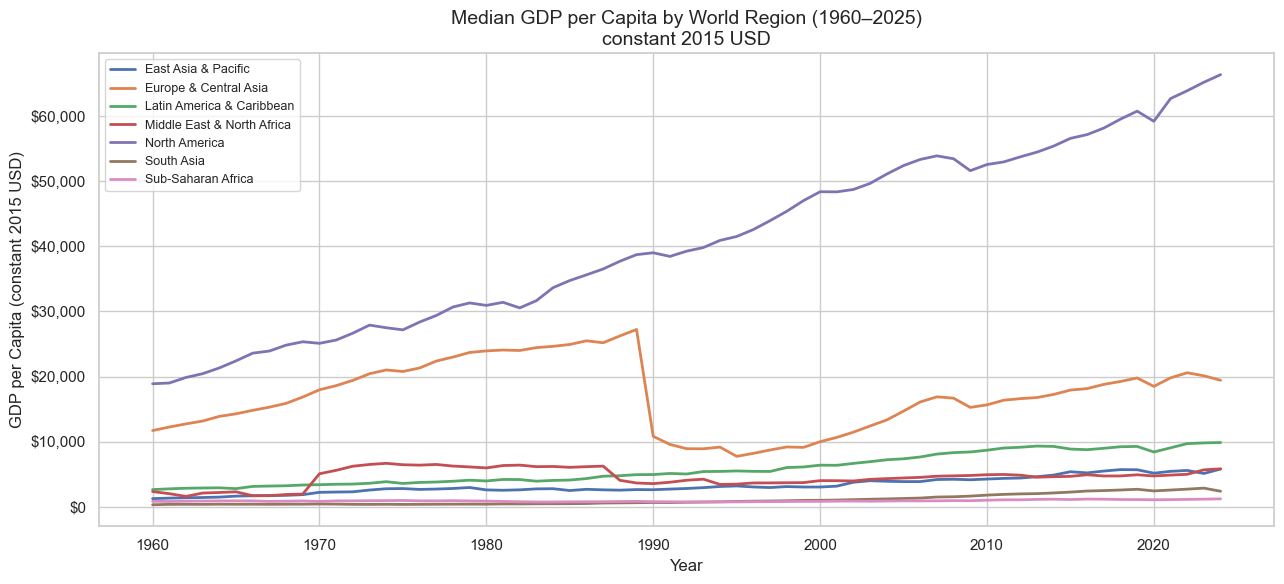

In [10]:
sns.set_theme(style="whitegrid", palette="muted")

PALETTE = {
    "East Asia & Pacific":        "#4C72B0",
    "Europe & Central Asia":      "#DD8452",
    "Latin America & Caribbean":  "#55A868",
    "Middle East & North Africa": "#C44E52",
    "North America":              "#8172B3",
    "South Asia":                 "#937860",
    "Sub-Saharan Africa":         "#DA8BC3",
}

region_trend = (
    df_countries.groupby(["Year", "Region"])["GDP_per_capita"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))

for region, grp in region_trend.groupby("Region"):
    color = PALETTE.get(region, "#999999")
    ax.plot(grp["Year"], grp["GDP_per_capita"], label=region, color=color, linewidth=2)

ax.set_title("Median GDP per Capita by World Region (1960–2025)\nconstant 2015 USD", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("GDP per Capita (constant 2015 USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

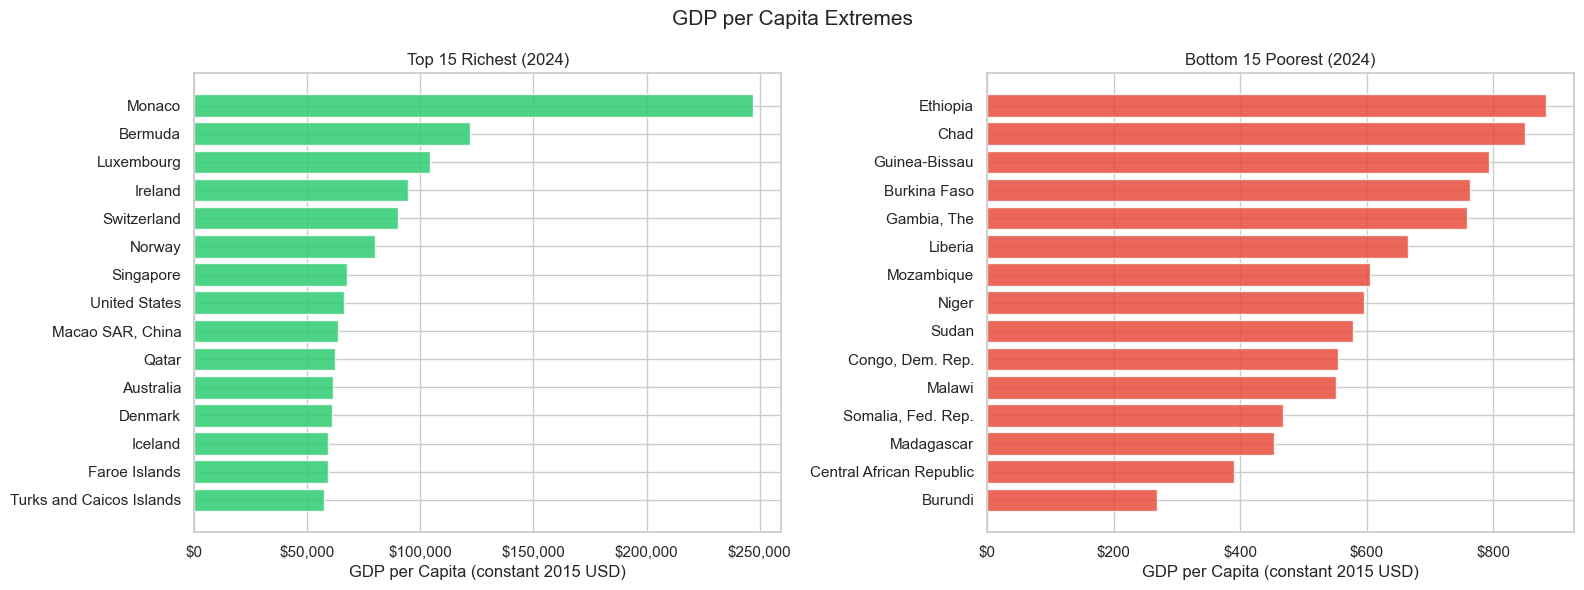

Latest year used: 2024


In [11]:
latest_year = df_countries.dropna(subset=["GDP_per_capita"])["Year"].max()
df_latest = df_countries[df_countries["Year"] == latest_year].dropna(subset=["GDP_per_capita"])

top15    = df_latest.nlargest(15, "GDP_per_capita")
bottom15 = df_latest.nsmallest(15, "GDP_per_capita")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, color in zip(
    axes,
    [top15, bottom15],
    [f"Top 15 Richest ({latest_year})", f"Bottom 15 Poorest ({latest_year})"],
    ["#2ecc71", "#e74c3c"]
):
    data_sorted = data.sort_values("GDP_per_capita", ascending=True)
    ax.barh(data_sorted["Country Name"], data_sorted["GDP_per_capita"], color=color, alpha=0.85)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("GDP per Capita (constant 2015 USD)")

plt.suptitle("GDP per Capita Extremes", fontsize=15)
plt.tight_layout()
plt.show()

print("Latest year used:", latest_year)

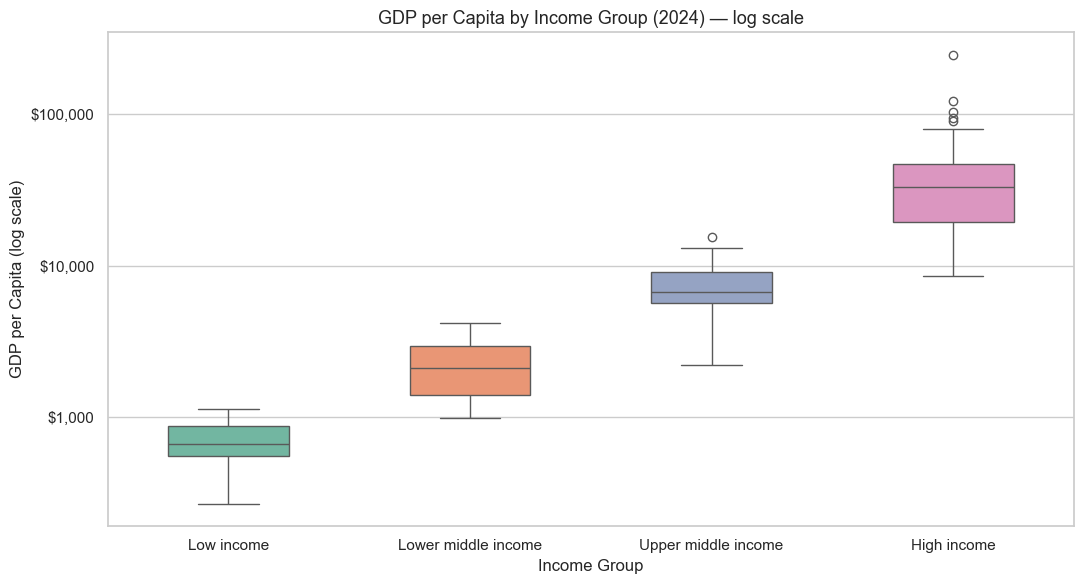

In [12]:
order = ["Low income", "Lower middle income", "Upper middle income", "High income"]
df_box = df_latest[df_latest["IncomeGroup"].isin(order)]

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df_box, x="IncomeGroup", y="GDP_per_capita",
    order=order, palette="Set2", ax=ax, width=0.5
)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title(f"GDP per Capita by Income Group ({latest_year}) — log scale", fontsize=13)
ax.set_xlabel("Income Group")
ax.set_ylabel("GDP per Capita (log scale)")
plt.tight_layout()
plt.show()

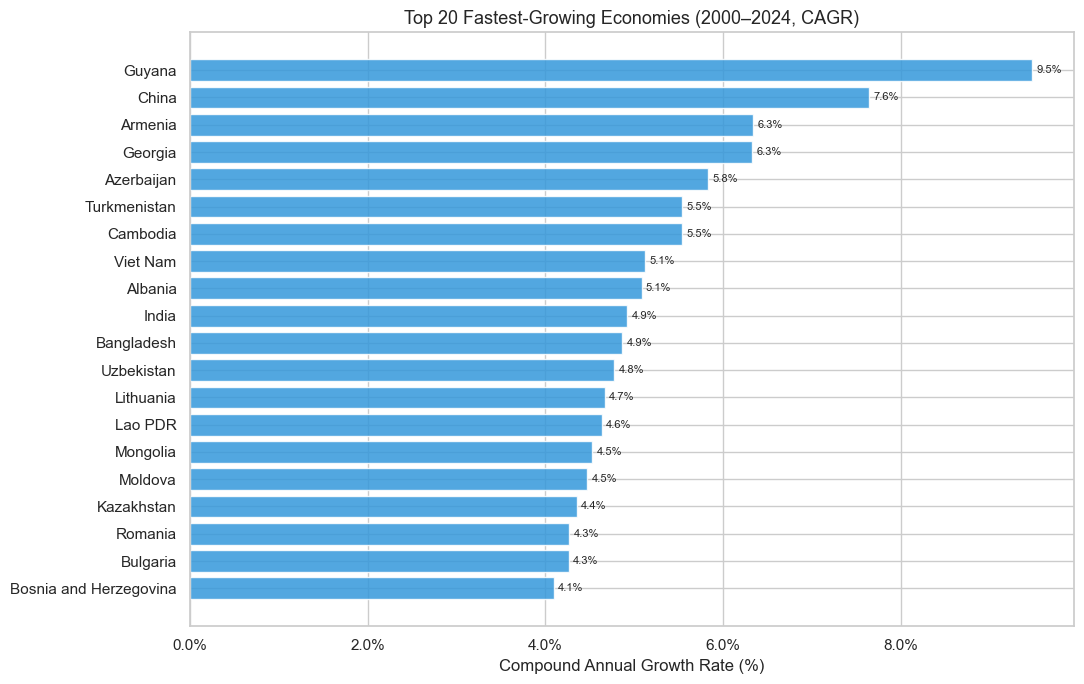

In [13]:
START_YEAR = 2000

df_start = (
    df_countries[df_countries["Year"] == START_YEAR]
    [["Country Name", "Country Code", "Region", "GDP_per_capita"]]
    .rename(columns={"GDP_per_capita": "gdp_start"})
)
df_end = (
    df_countries[df_countries["Year"] == latest_year]
    [["Country Code", "GDP_per_capita"]]
    .rename(columns={"GDP_per_capita": "gdp_end"})
)

df_growth = df_start.merge(df_end, on="Country Code").dropna()
df_growth = df_growth[df_growth["gdp_start"] > 500]  # remove near-zero bases
n_years = latest_year - START_YEAR
df_growth["CAGR"] = (df_growth["gdp_end"] / df_growth["gdp_start"]) ** (1 / n_years) - 1

top_growers = df_growth.nlargest(20, "CAGR").sort_values("CAGR")

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_growers["Country Name"], top_growers["CAGR"] * 100, color="#3498db", alpha=0.85)

for bar, val in zip(bars, top_growers["CAGR"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val*100:.1f}%", va="center", fontsize=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.set_title(f"Top 20 Fastest-Growing Economies ({START_YEAR}–{latest_year}, CAGR)", fontsize=13)
ax.set_xlabel("Compound Annual Growth Rate (%)")
plt.tight_layout()
plt.show()

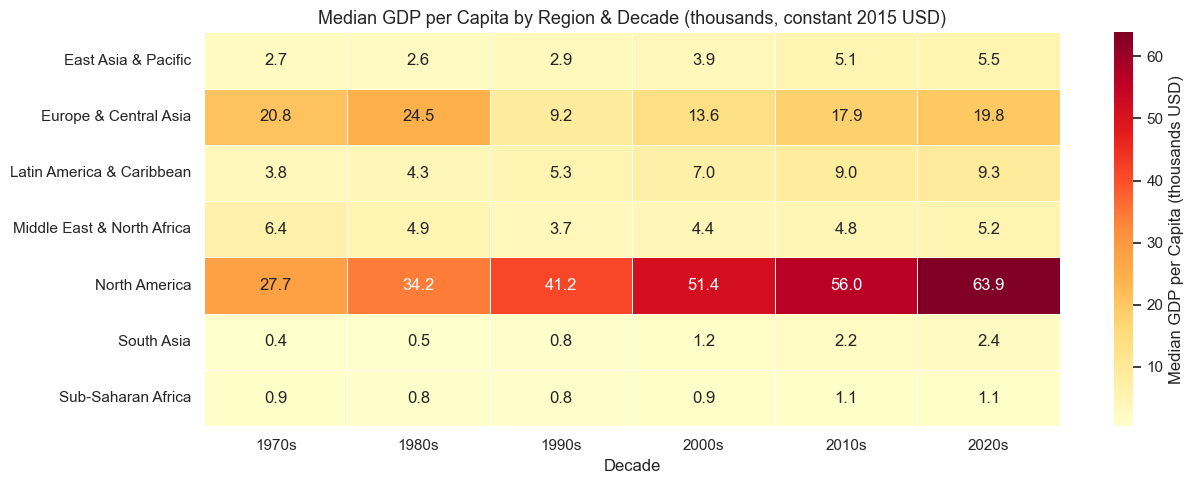

In [14]:
df_countries["Decade"] = (df_countries["Year"] // 10 * 10).astype(str) + "s"

heat = (
    df_countries[df_countries["Year"] >= 1970]
    .groupby(["Region", "Decade"])["GDP_per_capita"]
    .median()
    .unstack("Decade")
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    heat / 1000, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.4, ax=ax,
    cbar_kws={"label": "Median GDP per Capita (thousands USD)"}
)
ax.set_title("Median GDP per Capita by Region & Decade (thousands, constant 2015 USD)", fontsize=13)
ax.set_xlabel("Decade")
ax.set_ylabel("")
plt.tight_layout()
plt.show()